In [7]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import sys
print(sys.executable)
import pandas as pd 
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

print("Success!")

/opt/anaconda3/bin/python
Success!


predicting freight cost 

In [7]:
con = sqlite3.connect("/Users/sumanpakira/Desktop/minor_project_6/data/inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",con)


In [8]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [9]:
for table in tables['name']:
    print("Table name:", table)

    df = pd.read_sql_query(
        f"SELECT * FROM {table} LIMIT 5",
        con
    )

    display(df)

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [10]:
vendor_df = pd.read_sql_query("select * from vendor_invoice",con)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [11]:
vendor_df[["Quantity", "Freight", "Dollars"]].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


In [12]:
vendor_df['freight_per_unit'] = (
    vendor_df['Freight'] / vendor_df['Quantity']
)
print(vendor_df)

      VendorNumber                   VendorName InvoiceDate  PONumber  \
0              105  ALTAMAR BRANDS LLC           2024-01-04      8124   
1             4466  AMERICAN VINTAGE BEVERAGE    2024-01-07      8137   
2              388  ATLANTIC IMPORTING COMPANY   2024-01-09      8169   
3              480  BACARDI USA INC              2024-01-12      8106   
4              516  BANFI PRODUCTS CORP          2024-01-07      8170   
...            ...                          ...         ...       ...   
5538          9622  WEIN BAUER INC               2025-01-06     13626   
5539          9625  WESTERN SPIRITS BEVERAGE CO  2025-01-10     13661   
5540          3664  WILLIAM GRANT & SONS INC     2025-01-02     13643   
5541          9815  WINE GROUP INC               2025-01-03     13602   
5542         90058  ZORVINO VINEYARDS            2025-01-05     13574   

          PODate     PayDate  Quantity    Dollars  Freight Approval  \
0     2023-12-21  2024-02-16         6     214.26   

In [13]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

print("Q1 (25th percentile):", low_quantity)
print("Q3 (75th percentile):", high_quantity)

Q1 (25th percentile): 83.0
Q3 (75th percentile): 5100.5


In [14]:
low_avg = vendor_df.loc[
    vendor_df['Quantity'] < low_quantity,
    'freight_per_unit'
].mean()

high_avg = vendor_df.loc[
    vendor_df['Quantity'] > high_quantity,
    'freight_per_unit'
].mean()

print("Low quantity avg freight/unit:", low_avg)
print("High quantity avg freight/unit:", high_avg)

Low quantity avg freight/unit: 0.09489854253138316
High quantity avg freight/unit: 0.049077654690759046


In [25]:
x=vendor_df[['Dollars']] #fetures 
y=vendor_df['Freight'] #target

vendor_df.describe().round()


,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [16]:
%pip install scikit-learn
from sklearn.model_selection import train_test_split

Note: you may need to restart the kernel to use updated packages.


In [26]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [28]:
model1 = LinearRegression()
model1.fit(x_train, y_train)

model2 = DecisionTreeRegressor(max_depth = 4 ,random_state=42)
model2.fit(x_train, y_train)

model3 = RandomForestRegressor(max_depth = 5,random_state=42)
model3.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, x_test, y_test, model_name):
    preds = model.predict(x_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)*100

    print(f"\n{model_name}")
    print("-" * 30)
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [30]:
evaluate_model(model1, x_test, y_test, "Linear Regression")
evaluate_model(model2, x_test, y_test, "Decision Tree")

evaluate_model(model3, x_test, y_test, "Random Forest")


Linear Regression
------------------------------
MAE  : 24.11
MSE  : 15555.32
RMSE : 124.72
R²   : 96.9879

Decision Tree
------------------------------
MAE  : 38.12
MSE  : 19112.51
RMSE : 138.25
R²   : 96.2991

Random Forest
------------------------------
MAE  : 27.20
MSE  : 17359.89
RMSE : 131.76
R²   : 96.6384


{'Model': 'Random Forest',
 'MAE': 27.203783506953165,
 'MSE': 17359.892637830188,
 'RMSE': np.float64(131.75694531154775),
 'R2': 96.63844042693471}

(1109, 1)


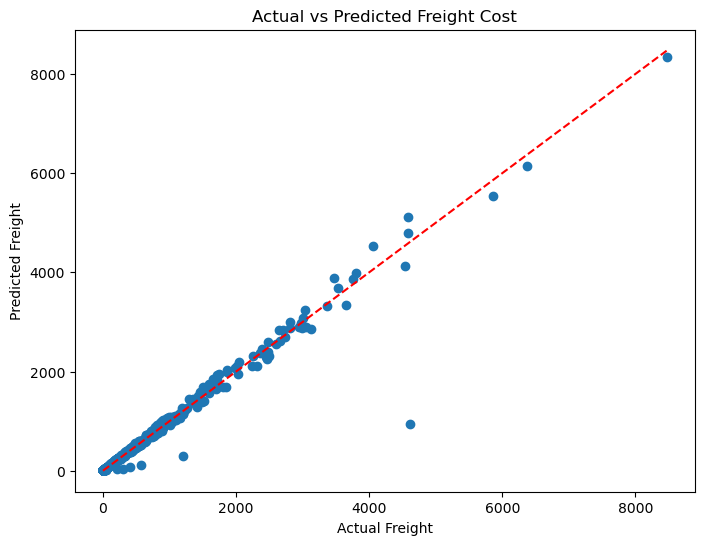

In [31]:
# plt.scatter(x_test , y_test)
# plt.plot(x_test,model1.predict(x_test),color='red')
print(x_test.shape)

y_pred = model1.predict(x_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Freight")
plt.ylabel("Predicted Freight")
plt.title("Actual vs Predicted Freight Cost")
plt.show()


In [33]:
input_data = {
    "Dollars": [18500, 9000]
}

df = pd.DataFrame(input_data)

predictions = model1.predict(df)
print(predictions)

[97.78868161 50.14455838]


In [38]:
x = vendor_df[['Dollars']]
y = vendor_df['Freight']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(x_train, y_train)

import joblib
from pathlib import Path
model_path = Path("/Users/sumanpakira/Desktop/minor_project_6/models/predict_freight_model.pkl")
joblib.dump(model1, model_path)
print("Saved:", model_path)

Saved: /Users/sumanpakira/Desktop/minor_project_6/models/predict_freight_model.pkl


In [39]:
print(model_path.exists())

True
